In [1]:
# Cell 1
import rioxarray
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

# Load the Optical Red band and the SAR VH band
optical_red = rioxarray.open_rasterio("data/s2_B04.tif").squeeze()
sar_vh = rioxarray.open_rasterio("data/s1_vh.tif").squeeze()

print("Data loaded!")


Data loaded!


In [2]:
# Cell 2
print(f"Optical Shape: {optical_red.shape}")
print(f"SAR Shape: {sar_vh.shape}")

if optical_red.shape != sar_vh.shape:
    print("WARNING: The images do not have the same number of pixels!")
    print("If you fed this to an AI, it would crash.")


Optical Shape: (1120, 1066)
SAR Shape: (1120, 1066)


In [3]:
# Cell 3
print("Aligning SAR to Optical grid...")

# This one line of code performs complex geospatial math to snap the pixels together
sar_aligned = sar_vh.rio.reproject_match(optical_red)

print(f"New SAR Shape: {sar_aligned.shape}")
print(f"Optical Shape: {optical_red.shape}")
print("SUCCESS! They are now mathematically identical in size and location.")


Aligning SAR to Optical grid...
New SAR Shape: (1120, 1066)
Optical Shape: (1120, 1066)
SUCCESS! They are now mathematically identical in size and location.


C:\Users\Mobil\AppData\Local\Temp\ipykernel_36284\4102414112.py:4: RuntimeWarning: invalid value encountered in log10
  sar_plot = 10 * np.log10(sar_aligned.values + 1e-10) # SAR in decibels


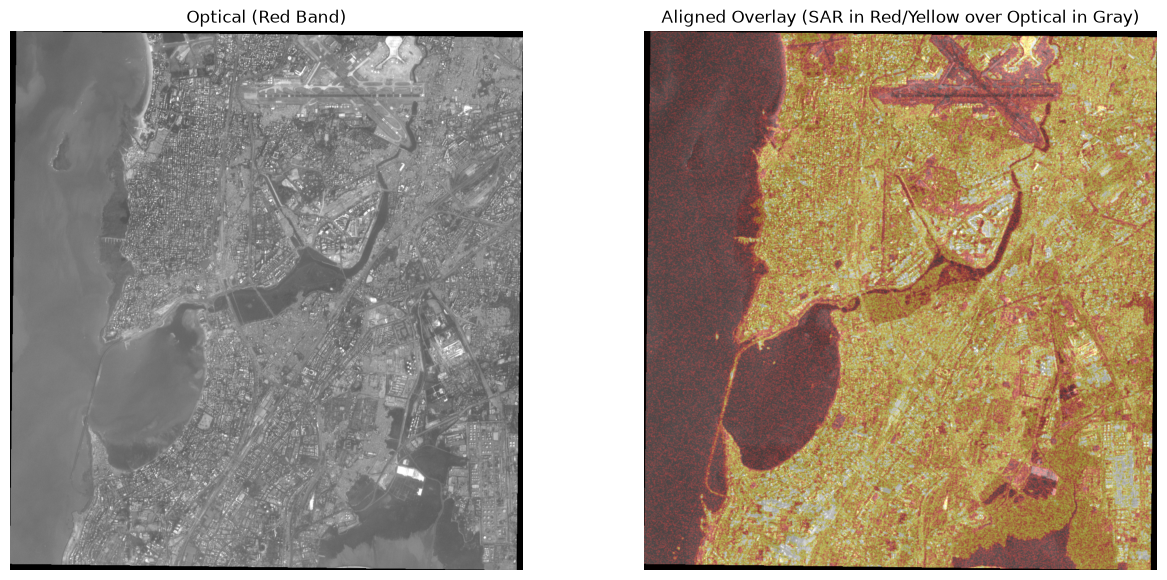

In [4]:
# Cell 4
# Let's clean up the data for plotting
opt_plot = np.clip(optical_red.values / 10000.0 * 2.5, 0.0, 1.0) # Brightened optical
sar_plot = 10 * np.log10(sar_aligned.values + 1e-10) # SAR in decibels

# Replace NaNs in SAR with a low value for plotting
sar_plot = np.nan_to_num(sar_plot, nan=-30.0)

# Create a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot 1: Just the Optical Image
axes[0].imshow(opt_plot, cmap='gray')
axes[0].set_title("Optical (Red Band)")
axes[0].axis('off')

# Plot 2: SAR overlayed on Optical
axes[1].imshow(opt_plot, cmap='gray')
# We overlay the SAR data using a 'hot' colormap, but make it 40% transparent (alpha=0.4)
axes[1].imshow(sar_plot, cmap='hot', alpha=0.4, vmin=-25, vmax=-5)
axes[1].set_title("Aligned Overlay (SAR in Red/Yellow over Optical in Gray)")
axes[1].axis('off')

plt.show()

# This final aligned matrix (Optical + SAR) is exactly what you will save 
# and feed into your deep learning models in Phase 2!
